**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Exploración y Curación de Datos**

*Edición 2025*

----

# Trabajo práctico entregable - parte 1

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
sns.set_context('talk')

from sqlalchemy import create_engine, text

In [46]:
import plotly
plotly.__version__


'5.24.1'

In [49]:
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')



## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar: df.to_sql() infiere tipos automáticamente, pero a veces los nombres de columnas como Date, Price o ID dan problemas si vienen con strings o valores nulos.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por ciudad.
    - cantidad de registros totales por barrio y ciudad.
    - Consulta con filtro: ¿Cuántas propiedades hay por ciudad con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (Type) y ciudad?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL  para obtener un resultado similar a lo realizado con Pandas en clase.  



# **Comenzaremos con el ejercicio 1**

Crearemos una base de datos local usando la librería SQLAlchemy, la cual llamaremos **engine**.

In [50]:

engine = create_engine('sqlite:///melbourne_airbnb.db')


Ahora necesitaremos importar el archivo hecho en clase. Nosotros lo haremos manualmente, ya que lo descargamos de la última clase.

In [125]:
interesting_cols = [
  'description', 'neighborhood_overview',
  'street', 'neighborhood', 'city', 'suburb', 'state', 'zipcode',
  'price', 'weekly_price', 'monthly_price',
  'latitude', 'longitude',
]
airbnb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv',
    usecols=interesting_cols)

KeyboardInterrupt: 

Ahora con pandas lo guardamos en el df

In [84]:

airbnb_df[:13]

,description,neighborhood_overview,street,neighborhood,city,suburb,state,zipcode,latitude,longitude,price,weekly_price,monthly_price
0,"House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,"Bulleen, VIC, Australia",Balwyn North,Manningham,Bulleen,VIC,3105,-37.772684,145.092133,60,NaN,NaN
1,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,"Brunswick East, VIC, Australia",Brunswick,Moreland,Brunswick East,VIC,3057,-37.766505,144.980736,35,200.0,803.0
2,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,"St Kilda, VIC, Australia",St Kilda,Port Phillip,St Kilda,VIC,3182,-37.859755,144.977369,159,1253.0,4452.0
3,"Comfortable, relaxed house, a home away from ...","This is a great neighbourhood – it is quiet, y...","Thornbury, VIC, Australia",Thornbury,Darebin,Thornbury,VIC,3071,-37.758971,144.989228,50,250.0,920.0
4,We offer comfortable accommodation in Inner Me...,NaN,"St Kilda East, VIC, Australia",St Kilda East,Port Phillip,St Kilda East,VIC,3183,-37.864530,144.992238,69,400.0,1900.0
5,Please note: No booking will be accepted with ...,Our street is quiet & secluded but within walk...,"Berwick, VIC, Australia",NaN,Casey,Berwick,VIC,3806,-38.057254,145.339356,98,540.0,NaN
6,Easy to travel from and to the Airport; quiet ...,"The neighbours are quiet and friendly, please...","Reservoir, VIC, Australia",NaN,Darebin,Reservoir,VIC,3073,-37.697294,145.000816,50,335.0,1400.0
7,Comfortable and spacious room in an apartment ...,MCG (15min walk) Rod Laver Arena Fitzroy Garde...,"East Melbourne, VIC, Australia",NaN,Melbourne,East Melbourne,VIC,3002,-37.810267,144.985920,100,NaN,NaN
8,Study the exquisite detail of the antique Java...,Oakleigh is one of the most convenient and div...,"Oakleigh East, VIC, Australia",NaN,Monash,Oakleigh East,VIC,3166,-37.899601,145.114475,98,535.0,NaN
9,Light filled private room with Queen bed taste...,NaN,"Frankston, VIC, Australia",NaN,Frankston,Frankston,VIC,3199,-38.149320,145.141569,60,413.0,1540.0


Ahora vamos a verificar los tipos de datos para no tener inconvenientes luego.





Comenzamos con el DataFrame Melbourne.

In [52]:
print(melb_df.dtypes)

Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object


Vemos que no hay ningún inconveniente, pero para trabajar más seguros transformaremos las fechas (Date) en tipo de dato **Date**.





In [53]:
melb_df['Date'] = pd.to_datetime(melb_df['Date'], errors='coerce')
print(melb_df.dtypes)

Suburb                   object
Address                  object
Rooms                     int64
Type                     object
Price                   float64
Method                   object
SellerG                  object
Date             datetime64[ns]
Distance                float64
Postcode                float64
Bedroom2                float64
Bathroom                float64
Car                     float64
Landsize                float64
BuildingArea            float64
YearBuilt               float64
CouncilArea              object
Lattitude               float64
Longtitude              float64
Regionname               object
Propertycount           float64
dtype: object


Tampoco le vemos sentido al Postcode como float; por lo tanto, lo transformaremos en entero.

In [111]:
melb_df['Postcode'] = melb_df['Postcode'].astype(int)

Ahora haremos la verificación con el DataFrame de Airbnb.

In [100]:
print(airbnb_df.dtypes)



description               object
neighborhood_overview     object
street                    object
neighborhood              object
city                      object
suburb                    object
state                     object
zipcode                  float64
latitude                 float64
longitude                float64
price                      int64
weekly_price             float64
monthly_price            float64
dtype: object


Vemos que el zipcode es un objeto; por lo tanto, tal y como se hizo en clase, lo pasaremos a float dejando solo la parte numérica.

In [109]:
# Extraer solo los dígitos de la columna 'zipcode'
airbnb_df['zipcode'] = airbnb_df['zipcode'].str.extract('(\d+)')

# Convertir a numérico
airbnb_df['zipcode'] = pd.to_numeric(airbnb_df['zipcode'], errors='coerce')

# Convertir a entero permitiendo NaN
airbnb_df['zipcode'] = airbnb_df['zipcode'].astype('Int64')


In [110]:
airbnb_df[:13]

,description,neighborhood_overview,street,neighborhood,city,suburb,state,zipcode,latitude,longitude,price,weekly_price,monthly_price
0,"House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,"Bulleen, VIC, Australia",Balwyn North,Manningham,Bulleen,VIC,3105,-37.772684,145.092133,60,NaN,NaN
1,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,"Brunswick East, VIC, Australia",Brunswick,Moreland,Brunswick East,VIC,3057,-37.766505,144.980736,35,200.0,803.0
2,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,"St Kilda, VIC, Australia",St Kilda,Port Phillip,St Kilda,VIC,3182,-37.859755,144.977369,159,1253.0,4452.0
3,"Comfortable, relaxed house, a home away from ...","This is a great neighbourhood – it is quiet, y...","Thornbury, VIC, Australia",Thornbury,Darebin,Thornbury,VIC,3071,-37.758971,144.989228,50,250.0,920.0
4,We offer comfortable accommodation in Inner Me...,NaN,"St Kilda East, VIC, Australia",St Kilda East,Port Phillip,St Kilda East,VIC,3183,-37.864530,144.992238,69,400.0,1900.0
5,Please note: No booking will be accepted with ...,Our street is quiet & secluded but within walk...,"Berwick, VIC, Australia",NaN,Casey,Berwick,VIC,3806,-38.057254,145.339356,98,540.0,NaN
6,Easy to travel from and to the Airport; quiet ...,"The neighbours are quiet and friendly, please...","Reservoir, VIC, Australia",NaN,Darebin,Reservoir,VIC,3073,-37.697294,145.000816,50,335.0,1400.0
7,Comfortable and spacious room in an apartment ...,MCG (15min walk) Rod Laver Arena Fitzroy Garde...,"East Melbourne, VIC, Australia",NaN,Melbourne,East Melbourne,VIC,3002,-37.810267,144.985920,100,NaN,NaN
8,Study the exquisite detail of the antique Java...,Oakleigh is one of the most convenient and div...,"Oakleigh East, VIC, Australia",NaN,Monash,Oakleigh East,VIC,3166,-37.899601,145.114475,98,535.0,NaN
9,Light filled private room with Queen bed taste...,NaN,"Frankston, VIC, Australia",NaN,Frankston,Frankston,VIC,3199,-38.149320,145.141569,60,413.0,1540.0


Ahora vamos a combertir ambos data frame en tablas en la base de datos sql

In [88]:
melb_df.to_sql("melbourne", engine, index=False, if_exists="replace")
airbnb_df.to_sql("airbnb", engine, index=False, if_exists="replace")

22895

Una vez realizada la importación a bases de datos SQL, haremos las consultas requeridas en el enunciado.

**Cantidad de registros por ciudad**

El siguiente código los agrupa por ciudad y los ordena de mayor a menor.

In [55]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT CouncilArea AS ciudad, COUNT(*) AS cantidad
        FROM melbourne
        GROUP BY ciudad
        ORDER BY cantidad DESC
    """)).fetchall()

# Mostramos los resultados
for row in result:
    print(row)

(None, 1369)
('Moreland', 1163)
('Boroondara', 1160)
('Moonee Valley', 997)
('Darebin', 934)
('Glen Eira', 848)
('Stonnington', 719)
('Maribyrnong', 692)
('Yarra', 647)
('Port Phillip', 628)
('Banyule', 594)
('Bayside', 489)
('Melbourne', 470)
('Hobsons Bay', 434)
('Brimbank', 424)
('Monash', 333)
('Manningham', 311)
('Whitehorse', 304)
('Kingston', 207)
('Whittlesea', 167)
('Hume', 164)
('Wyndham', 86)
('Maroondah', 80)
('Knox', 80)
('Melton', 66)
('Frankston', 53)
('Greater Dandenong', 52)
('Casey', 38)
('Nillumbik', 36)
('Yarra Ranges', 18)
('Cardinia', 8)
('Macedon Ranges', 7)
('Unavailable', 1)
('Moorabool', 1)


**Registros por barrio y ciudad**

In [56]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT Suburb AS barrio, CouncilArea AS ciudad, COUNT(*) AS cantidad
        FROM melbourne
        GROUP BY barrio, ciudad
        ORDER BY cantidad DESC
        LIMIT 10
    """)).fetchall()

for row in result:
    print(row)

('Reservoir', 'Darebin', 323)
('Richmond', 'Yarra', 251)
('Bentleigh East', 'Glen Eira', 234)
('Preston', 'Darebin', 228)
('Brunswick', 'Moreland', 208)
('Essendon', 'Moonee Valley', 208)
('Hawthorn', 'Boroondara', 186)
('Brighton', 'Bayside', 176)
('Coburg', 'Moreland', 176)
('Northcote', 'Darebin', 175)


limitamos a 10 porque eran demasiados datos

**Propiedades con más de 2 habitaciones por ciudad**

In [57]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT CouncilArea AS ciudad, COUNT(*) AS cantidad
        FROM melbourne
        WHERE Rooms > 2
        GROUP BY ciudad
        ORDER BY cantidad DESC
    """)).fetchall()

for row in result:
    print(row)

(None, 1201)
('Boroondara', 791)
('Moreland', 777)
('Moonee Valley', 713)
('Darebin', 592)
('Glen Eira', 531)
('Banyule', 441)
('Maribyrnong', 434)
('Brimbank', 376)
('Bayside', 360)
('Hobsons Bay', 330)
('Stonnington', 304)
('Manningham', 295)
('Monash', 280)
('Yarra', 264)
('Whitehorse', 240)
('Port Phillip', 220)
('Kingston', 169)
('Hume', 152)
('Whittlesea', 149)
('Melbourne', 145)
('Wyndham', 82)
('Knox', 75)
('Maroondah', 68)
('Melton', 64)
('Frankston', 49)
('Greater Dandenong', 45)
('Casey', 37)
('Nillumbik', 34)
('Yarra Ranges', 17)
('Macedon Ranges', 7)
('Cardinia', 7)
('Unavailable', 1)
('Moorabool', 1)


**Precio promedio por tipo y ciudad**

In [58]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT Type, CouncilArea AS ciudad, AVG(Price) AS precio_promedio
        FROM melbourne
        GROUP BY Type, ciudad
        ORDER BY precio_promedio DESC
    """)).fetchall()

for row in result:
    print(row)

('h', 'Boroondara', 2098358.8624338624)
('h', 'Stonnington', 2009337.4823151126)
('h', 'Bayside', 1986762.6623794213)
('h', 'Port Phillip', 1776054.716981132)
('t', 'Bayside', 1465253.8461538462)
('h', 'Whitehorse', 1437365.238095238)
('h', 'Melbourne', 1405010.3896103897)
('h', 'Yarra', 1387058.4825870646)
('t', 'Stonnington', 1371860.0)
('h', 'Glen Eira', 1352435.0808510638)
('h', 'Unavailable', 1325000.0)
('h', 'Manningham', 1312930.888030888)
('h', 'Monash', 1289668.2730923695)
('t', 'Boroondara', 1275743.6170212766)
('t', 'Port Phillip', 1255000.0)
('h', None, 1211861.2859437752)
('h', 'Moonee Valley', 1146283.640113798)
('h', 'Hobsons Bay', 1123561.6666666667)
('h', 'Kingston', 1069312.731543624)
('t', None, 1063550.7246376812)
('h', 'Darebin', 1059167.2554426705)
('t', 'Yarra', 1041978.7234042553)
('h', 'Banyule', 1029602.3706896552)
('t', 'Glen Eira', 1005799.1071428572)
('t', 'Manningham', 947950.0)
('t', 'Melbourne', 946287.5)
('h', 'Maribyrnong', 938990.5349794239)
('t', 'Wh

**Top 5 barrios con propiedades más caras**

In [59]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT Suburb AS barrio, AVG(Price) AS precio_promedio
        FROM melbourne
        GROUP BY barrio
        ORDER BY precio_promedio DESC
        LIMIT 5
    """)).fetchall()

for row in result:
    print(row)

('Kooyong', 2185000.0)
('Canterbury', 2180240.7407407407)
('Middle Park', 2082529.4117647058)
('Albert Park', 1941355.072463768)
('Brighton', 1930158.0)


Ahora realizamos el ultimo punto

Lo limitaremos a 10 porque el resultado es demasiado grande.


In [60]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT m.Suburb, m.Postcode, m.Price,
               a.airbnb_price_mean, a.airbnb_weekly_price_mean, a.airbnb_monthly_price_mean
        FROM melbourne m
        JOIN airbnb a ON m.Postcode = a.zipcode
        LIMIT 10
    """)).fetchall()

for row in result:
    print(row)


('Abbotsford', 3067.0, 1480000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067.0, 1035000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067.0, 1465000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067.0, 850000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067.0, 1600000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067.0, 941000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067.0, 1876000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067.0, 1636000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067.0, 300000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)
('Abbotsford', 3067.0, 1097000.0, 130.62403100775194, 605.1521739130435, 2187.032258064516)


## Ejercicio 2 - Pandas:

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2.  Mostrar la dispersión o distribución de las columnas seleccionadas.
 3.  Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás



2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (porque no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación.
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?

--------------------------------------------------------------------------------------------------------

Comenzaremos seleccionando las variables relevantes para la prediccion del valor de la porpiedad

**Variables seleccionadas:**



*   **Suburb**: aporta contexto geográfico, muy influyente en los precios.
*   **Rooms**: cantidad de habitaciones influye directamente en el valor.
*   **Type**: tipo de propiedad (casa, departamento, townhouse).
*   **Method**: forma de venta (auction, private, etc.) puede afectar precio.
*   **Distance**: cercanía al centro de Melbourne.
*   **CouncilArea**: barrio o distrito, fuerte relación con valor inmobiliario.
*   **Landsize**: tamaño del terreno, correlaciona con el precio.
*   **BuildingArea**: superficie construida.
*   **YearBuilt**: antigüedad de la propiedad.
*   **Bathroom**: cantidad de baños.
*   **Car**: capacidad de estacionamiento.
*   **Price**: variable objetivo.




**Variables no seleccionadas**



*   **SellerG**, **Address**, **Postcode**, **Regionname**: información redundante o difícil de modelar directamente.
*   **Date**: aunque podría ser útil para análisis temporal, no se incluyó porque no es el foco actual.



Ahora calcularemos el porcentaje de filas que tienen al menos un valor faltante

In [34]:
missing_rows_percent = melb_df.isnull().any(axis=1).mean() * 100


81.7820324005891


In [36]:
print(f"El porcentaje de filas que tienen al menos un valor faltante es: {missing_rows_percent:.2f}%")

El porcentaje de filas que tienen al menos un valor faltante es: 81.78%


Para el siguiente punto lo que haremos es selecionar las variables numericas para visualizar la distribucion

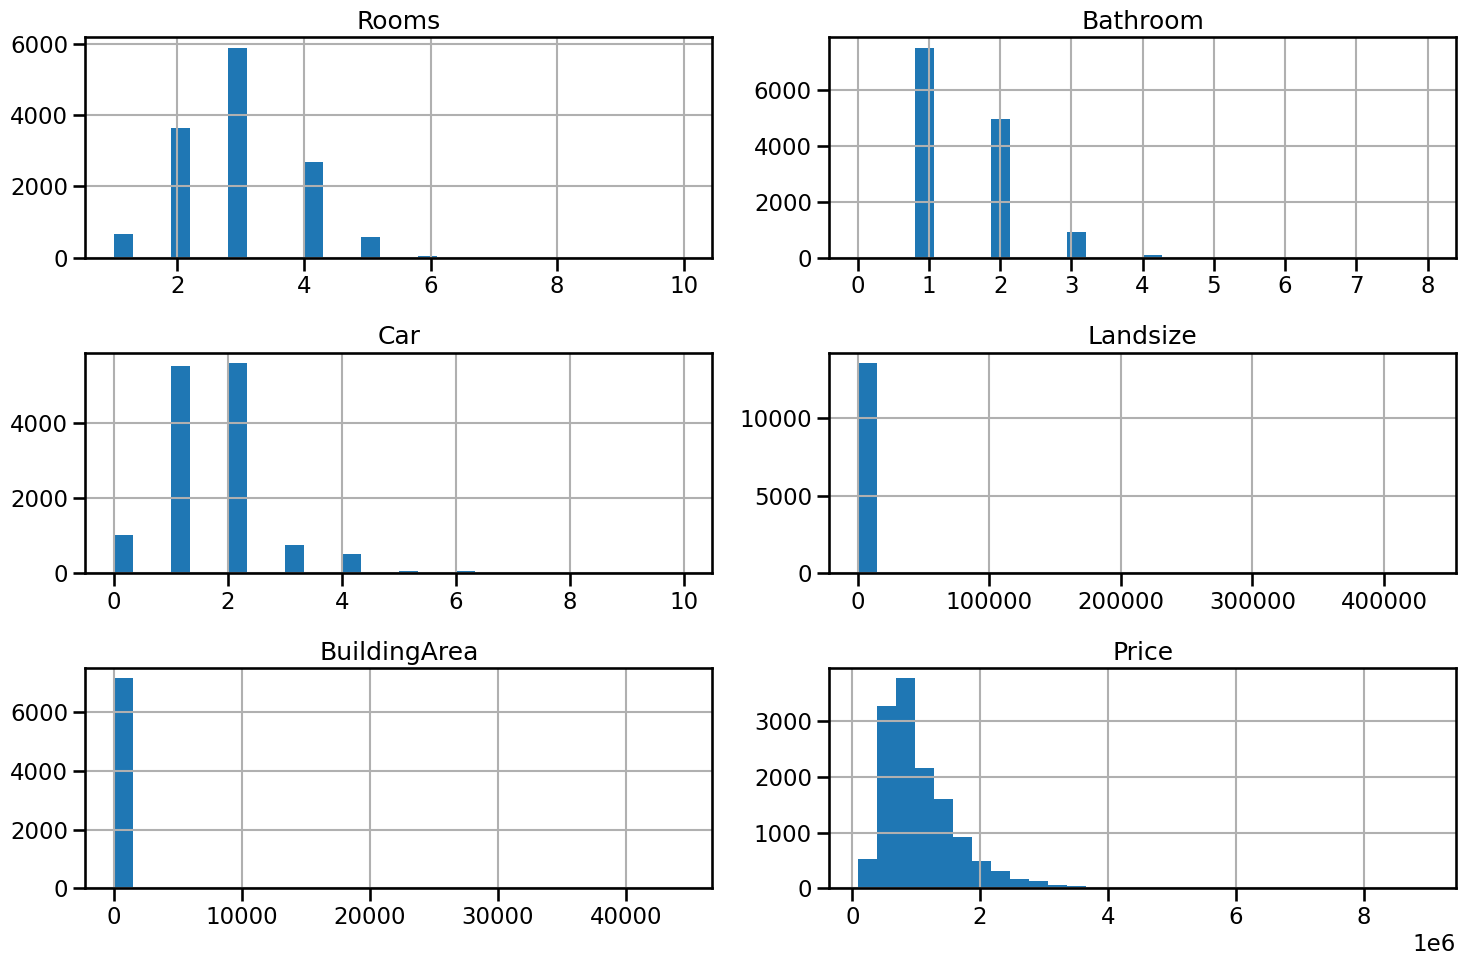

In [61]:
numeric_cols = ['Rooms', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Price']
melb_df[numeric_cols].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

Ahora para eliminar los valores extremos lo haremos por recorte percentil, eliminando el 1% superior y 1% inferior

In [72]:
for col in numeric_cols:
    lower = melb_df[col].quantile(0.01)
    upper = melb_df[col].quantile(0.99)
    melb_filt_df = melb_df[(melb_df[col] >= lower) & (melb_df[col] <= upper)]


# Graficamos

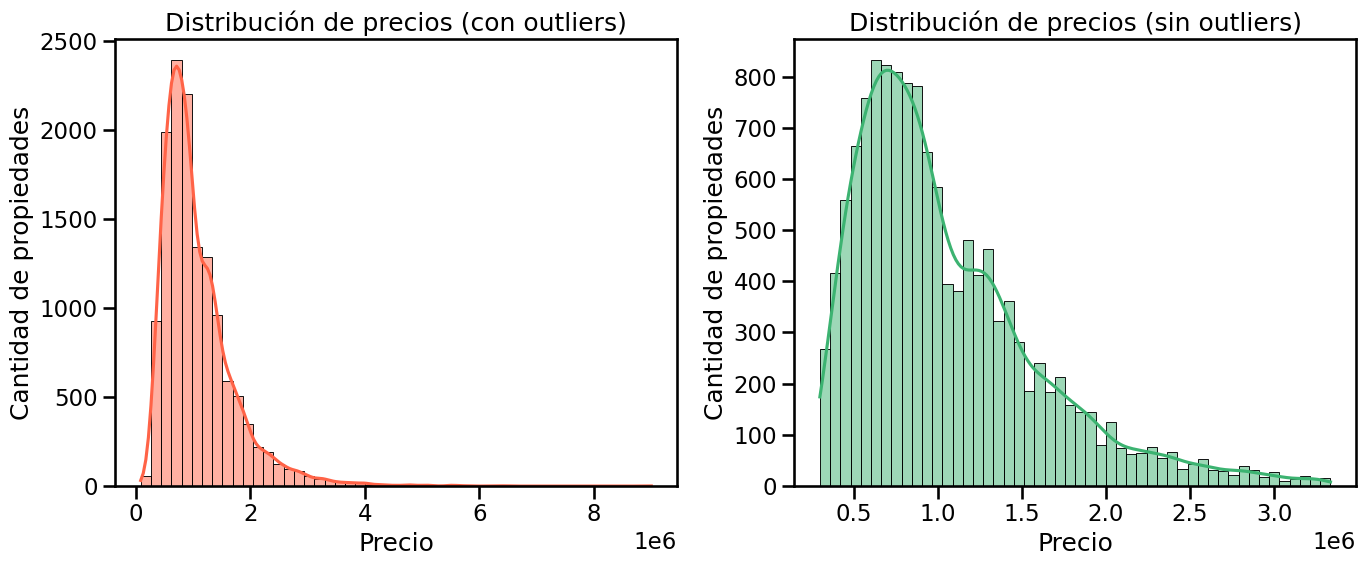

In [73]:
plt.figure(figsize=(14, 6))

# Original
plt.subplot(1, 2, 1)
sns.histplot(melb_df['Price'], bins=50, kde=True, color='tomato')
plt.title('Distribución de precios (con outliers)')
plt.xlabel('Precio')
plt.ylabel('Cantidad de propiedades')

# Sin outliers
plt.subplot(1, 2, 2)
sns.histplot(melb_filt_df['Price'], bins=50, kde=True, color='mediumseagreen')
plt.title('Distribución de precios (sin outliers)')
plt.xlabel('Precio')
plt.ylabel('Cantidad de propiedades')

plt.tight_layout()
plt.show()


Ahora haremos otra pruba pero excluyendo el 5% de cada extremo

In [69]:
for col in numeric_cols:
    lower = melb_df[col].quantile(0.05)
    upper = melb_df[col].quantile(0.95)
    melb_filt_df = melb_df[(melb_df[col] >= lower) & (melb_df[col] <= upper)]

Graficamos nuevamente

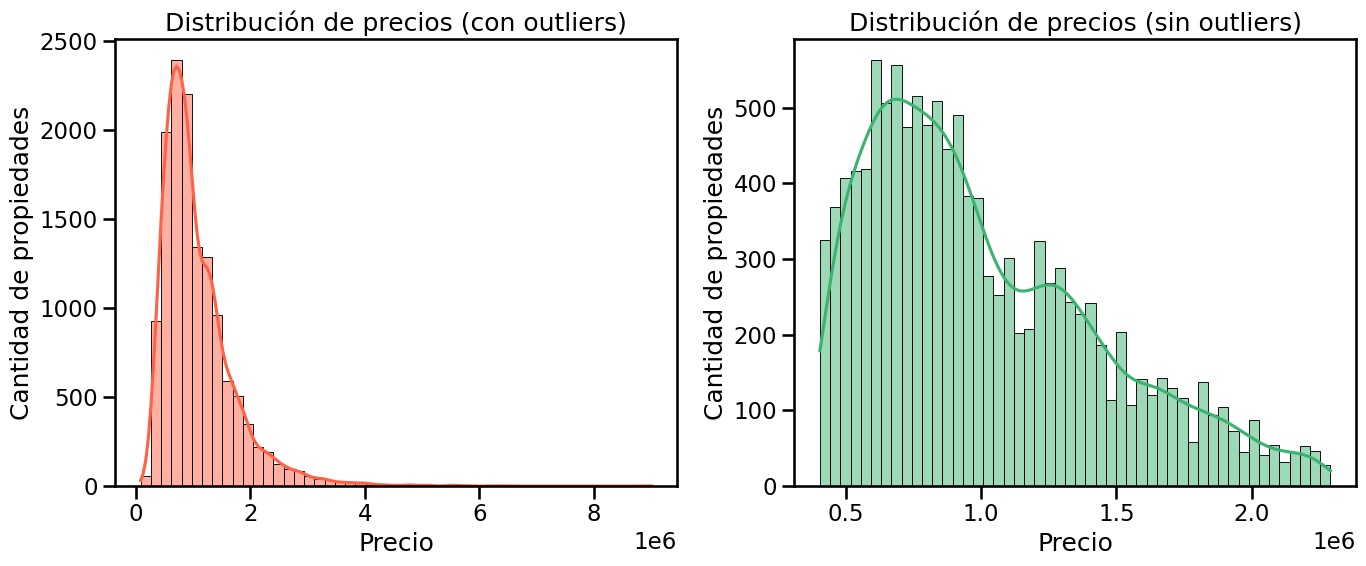

In [70]:
plt.figure(figsize=(14, 6))

# Original
plt.subplot(1, 2, 1)
sns.histplot(melb_df['Price'], bins=50, kde=True, color='tomato')
plt.title('Distribución de precios (con outliers)')
plt.xlabel('Precio')
plt.ylabel('Cantidad de propiedades')

# Sin outliers
plt.subplot(1, 2, 2)
sns.histplot(melb_filt_df['Price'], bins=50, kde=True, color='mediumseagreen')
plt.title('Distribución de precios (sin outliers)')
plt.xlabel('Precio')
plt.ylabel('Cantidad de propiedades')

plt.tight_layout()
plt.show()


Ahora continuaremos con la segunda parte el ejercicio

Seleccionamos la variable **price** del conjunto de AirBnB porque refleja directamente el valor comercial por día de propiedades en cada zona. A partir de esta variable aplicamos las siguientes transformaciones agrupadas por **zipcode**:


*   **airbnb_price_median**: para evitar la sensibilidad a outliers.
*   **airbnb_price_mean**: para tener una referencia general.
*   **airbnb_price_min / max**: para conocer el rango del mercado.
*   **airbnb_record_count**: para saber si hay suficiente información en ese código postal.



Justificando el uso de mediana en lugar de la media para valores de precios porque suele haber grandes extremos que distorsionan la media, especialmente en alquileres diarios donde hay propiedades de lujo o con servicios premium.

Usamos zipcode como variable común entre los datasets. Para garantizar que la información agregada tenga sentido estadístico, decidimos **filtrar los códigos postales que tengan al menos 5 registros** en AirBnB.

In [112]:
airbnb_agg = airbnb_df.groupby("zipcode").agg(
    airbnb_price_median=('price', 'median'),
    airbnb_price_mean=('price', 'mean'),
    airbnb_price_min=('price', 'min'),
    airbnb_price_max=('price', 'max'),
    airbnb_record_count=('price', 'count')
).reset_index()

# Filtramos los que tienen al menos 5 registros
airbnb_agg_filtered = airbnb_agg[airbnb_agg['airbnb_record_count'] >= 5]

# Unimos con el dataset principal
df_merged = melb_df.merge(airbnb_agg_filtered, how='left', left_on='Postcode', right_on='zipcode')


In [114]:
df_merged[:10]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Lattitude,Longtitude,Regionname,Propertycount,zipcode,airbnb_price_median,airbnb_price_mean,airbnb_price_min,airbnb_price_max,airbnb_record_count
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067,...,-37.7996,144.9984,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067,...,-37.8079,144.9934,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067,...,-37.8093,144.9944,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-04-03,2.5,3067,...,-37.7969,144.9969,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-04-06,2.5,3067,...,-37.8072,144.9941,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0
5,Abbotsford,129 Charles St,2,h,941000.0,S,Jellis,2016-07-05,2.5,3067,...,-37.8041,144.9953,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0
6,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,2016-07-05,2.5,3067,...,-37.8024,144.9993,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0
7,Abbotsford,98 Charles St,2,h,1636000.0,S,Nelson,2016-08-10,2.5,3067,...,-37.8060,144.9954,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0
8,Abbotsford,6/241 Nicholson St,1,u,300000.0,S,Biggin,2016-08-10,2.5,3067,...,-37.8008,144.9973,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0
9,Abbotsford,10 Valiant St,2,h,1097000.0,S,Biggin,2016-08-10,2.5,3067,...,-37.8010,144.9989,Northern Metropolitan,4019.0,3067,96.0,115.594059,30.0,400.0,101.0


Ahora graficaremos


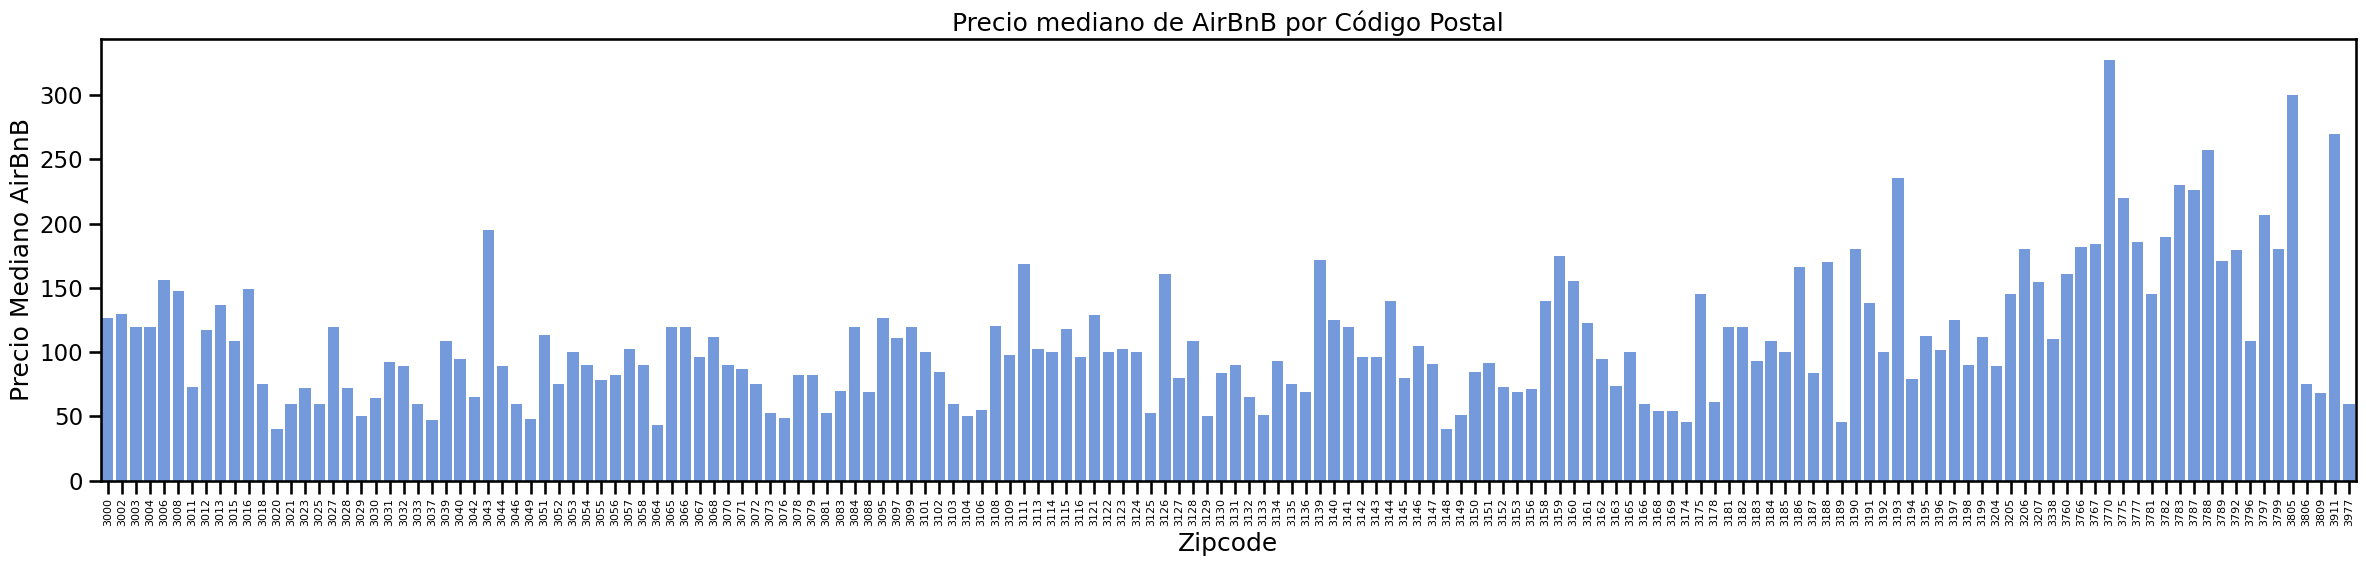

In [113]:
plt.figure(figsize=(24, 6))
sns.barplot(data=airbnb_agg_filtered, x='zipcode', y='airbnb_price_median', color='cornflowerblue')
plt.xticks(rotation=90)
plt.title('Precio mediano de AirBnB por Código Postal')
plt.xlabel('Zipcode')
plt.ylabel('Precio Mediano AirBnB')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

Además de **zipcode**, proponemos dos variables para enriquecer el dataset:



1.   **Suburb o CouncilArea**: Puede haber coincidencias entre los nombres de barrios de ambos datasets. Esto permite agrupar propiedades por zonas conocidas
2.  **Coordenadas geográficas**: Podríamos cruzar cada propiedad del dataset principal con los AirBnB más cercanos. Esto daría un contexto más preciso que zipcode, que puede ser demasiado amplio.



Creemos que la cercanía espacial es un factor clave en el valor inmobiliario, y muchas veces barrios limítrofes pueden tener diferencias importantes de precios.

Si tuviéramos las coordenadas tanto de las propiedades como de las publicaciones de AirBnB, podríamos:



*   Calcular la distancia a las 5-10 propiedades más cercanas listadas en AirBnB y hacer un promedio ponderado por distancia del precio.
*   Obtener características como la densidad de publicaciones cercanas o el precio promedio en un radio de 1 km.



Esto agregaría contexto micro-local muy relevante que no se capta solo con zipcode

Algunos de los datos que concideramos que faltan y nos gustaria tener son los siguientes:



*   Características del barrio, nivel de seguridad, acceso a transporte, calidad de escuelas.

*   Año de renovación de las propiedades.
*   Estado de conservación o fotos.
*   Datos históricos de precios o valor de mercado de propiedades cercanas
*   Cantidad de visitas o demanda de propiedades similares.




Estos datos nos permitirían construir un modelo más robusto que tenga en cuenta tanto factores estructurales como contextuales.

## Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

Para realizar este ejercicio nos basaremos en el codigo hecho en clases.

utilizamos el df_merged y lo copiamos a un df_final que es el que exportaremos a csv

In [115]:
df_final = df_merged.copy()

In [116]:
df_final.to_csv("Entregable_1.csv", index=False)

Ahora probaremos descargar el archivo

In [117]:
from google.colab import files
files.download('Entregable_1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Podemos verificar que funciona correctamente

## Ejercicios opcionales:

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)

Realizaremos un script en python que contiene transformacion y carga, agragandole tambien un download.

In [123]:
import pandas as pd

def extract_data():
    """Load datasets from CSV or sources."""
    melbourne = pd.read_csv(
        'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv'
    )
    airbnb = pd.read_csv(
        'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv',
        low_memory=False  # ← evita advertencias por tipos mixtos
    )
    return melbourne, airbnb

def transform_data(melbourne, airbnb):
    """Limpia, filtra, y enriquece el dataset."""
    # Filtramos columnas relevantes
    columnas_relevantes = [
        "Rooms", "Type", "Price", "Distance", "Postcode", "Bedroom2", "Bathroom",
        "Car", "Landsize", "BuildingArea", "YearBuilt", "Lattitude", "Longtitude"
    ]
    melbourne = melbourne[columnas_relevantes].copy()

    # Convertimos Postcode y zipcode a string
    melbourne["Postcode"] = melbourne["Postcode"].astype("Int64").astype(str)
    airbnb["zipcode"] = airbnb["zipcode"].astype(str)

    # Eliminamos outliers extremos en Price
    q1 = melbourne["Price"].quantile(0.01)
    q99 = melbourne["Price"].quantile(0.99)
    melbourne = melbourne[(melbourne["Price"] >= q1) & (melbourne["Price"] <= q99)]

    # Convertimos precios de AirBnB a float
    airbnb['price'] = airbnb['price'].replace('[\$,]', '', regex=True).astype(float)

    # Agrupamos por zipcode y calcular estadísticas
    airbnb_agg = airbnb.groupby("zipcode").agg(
        airbnb_price_median=('price', 'median'),
        airbnb_price_mean=('price', 'mean'),
        airbnb_price_min=('price', 'min'),
        airbnb_price_max=('price', 'max'),
        airbnb_record_count=('price', 'count')
    ).reset_index()

    # Filtramos por mínimo de registros (por ejemplo, 5)
    airbnb_filtered = airbnb_agg[airbnb_agg["airbnb_record_count"] >= 5]

    # Unimos datasets
    merged = melbourne.merge(
        airbnb_filtered,
        how="left",
        left_on="Postcode",
        right_on="zipcode"
    )

    return merged

def load_data(df_final):
    """Guarda el resultado final."""
    df_final.to_csv("Entregable_1.csv", index=False)

def download_file(file):
  files.download(file)

def main():
    melbourne, airbnb = extract_data()
    df_final = transform_data(melbourne, airbnb)
    load_data(df_final)
    download_file("Entregable_1.csv")

if __name__ == "__main__":
    main()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

En cuanto al punto 2 del ejercicio opcional, intentamos hacerlo en el Colab pero no reconoce algunas librerias por lo tanto no lo terminamos, ya que no podiamos probar errores